# Notebook 08 — Compare Mini-Network vs ResNet50 (frozen) vs ResNet50 (fine-tuned)

**Part 2 deliverable.** Three-way comparison of:

| Tag           | Model                              | Saved file                     | Pretrained?                  |
| ------------- | ---------------------------------- | ------------------------------ | ---------------------------- |
| `mininet`     | MiniCampusNet (Notebook 07)        | `mini_campusnet.pth`           | No (from scratch)            |
| `rn50_frozen` | ResNet50, head-only (Notebook 03)  | `resnet50_campus.pth`          | Yes, ImageNet                |
| `rn50_ft`     | ResNet50, fine-tuned (Notebook 06) | `resnet50_campus_improved.pth` | Yes, ImageNet, layer3+4 unfrozen |

We measure **test-set accuracy, per-class F1, parameter count, model size on disk, and inference latency**, then plot everything for the report.

## Cell 1 — Imports

In [1]:
import os, time, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models as tv_models
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## Cell 2 — Test-set loader (shared across all three models)

In [3]:
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_ds     = datasets.ImageFolder("C:/Users/darwa/Downloads/campus_navigation_project update/data/test", transform=tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
classes     = test_ds.classes
NUM_CLASSES = len(classes)

print(f"Test images : {len(test_ds)}")
print(f"Classes     : {classes}")

Test images : 49
Classes     : ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']


## Cell 3 — Model loaders

Each loader returns a model in `eval()` mode on `device`. The mini-net class is redeclared here so this notebook can run independently of Notebook 07.

In [5]:
# ── MiniCampusNet (re-declared so this notebook is self-contained) ──
class MiniCampusNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        def conv_bn(in_c, out_c, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))
        def dw_sep(in_c, out_c, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_c, in_c, 3, stride, 1, groups=in_c, bias=False),
                nn.BatchNorm2d(in_c), nn.ReLU(inplace=True),
                nn.Conv2d(in_c, out_c, 1, 1, 0, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))
        self.features = nn.Sequential(
            conv_bn(3,32,2), dw_sep(32,64,1), dw_sep(64,128,2),
            dw_sep(128,128,1), dw_sep(128,256,2), dw_sep(256,256,1),
            dw_sep(256,512,2), dw_sep(512,512,1), dw_sep(512,512,1),
            nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(512, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

def load_mininet(path="mini_campusnet.pth"):
    ckpt = torch.load(path, map_location=device)
    m = MiniCampusNet(num_classes=ckpt["num_classes"])
    m.load_state_dict(ckpt["model_state_dict"])
    return m.to(device).eval(), ckpt

def _resnet_with_head(num_classes, dropout=0.4):
    m = tv_models.resnet50(weights=None)
    m.fc = nn.Sequential(
        nn.Linear(2048, 512), nn.ReLU(),
        nn.Dropout(dropout), nn.Linear(512, num_classes))
    return m

def load_resnet(path):
    ckpt = torch.load(path, map_location=device)
    m = _resnet_with_head(ckpt["num_classes"])
    m.load_state_dict(ckpt["model_state_dict"])
    return m.to(device).eval(), ckpt

# Load all three
mininet,    mini_ckpt   = load_mininet("mini_campusnet.pth")
rn50_frozen, frozen_ckpt = load_resnet("C:/Users/darwa/Downloads/campus_navigation_project update/resnet50_campus_improved.pth")
rn50_ft,    ft_ckpt     = load_resnet("C:/Users/darwa/Downloads/campus_navigation_project update/resnet50_campus_improved.pth")

# Sanity check — all three must agree on the class ordering, otherwise
# label indices won't line up with prediction indices.
assert mini_ckpt["classes"] == frozen_ckpt["classes"] == ft_ckpt["classes"], \
    "Class lists differ across checkpoints — re-train so they match!"

print("✓ All three models loaded")
print(f"  Classes (shared): {mini_ckpt['classes']}")

✓ All three models loaded
  Classes (shared): ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']


## Cell 4 — Evaluation helper

One function that returns a dict of metrics per model: accuracy, macro-F1, parameter count, file size, latency, and the raw prediction arrays for plotting later.

In [8]:
def evaluate(model, loader, ckpt_path, name):
    """Run model over `loader`, compute metrics + latency."""
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds = model(x).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = 100 * accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")

    # Latency — single-image forward, averaged over 50 runs after a 5-run warmup
    dummy = torch.randn(1, 3, 224, 224, device=device)
    with torch.no_grad():
        for _ in range(5):                # warmup
            _ = model(dummy)
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(50):
            _ = model(dummy)
        if device == "cuda": torch.cuda.synchronize()
        latency_ms = (time.perf_counter() - t0) / 50 * 1000

    n_params  = sum(p.numel() for p in model.parameters())
    file_size_mb = os.path.getsize(ckpt_path) / (1024 * 1024)

    return {
        "name"        : name,
        "params"      : n_params,
        "file_mb"     : file_size_mb,
        "accuracy"    : acc,
        "macro_f1"    : f1,
        "latency_ms"  : latency_ms,
        "preds"       : all_preds,
        "labels"      : all_labels,
    }

results = [
    evaluate(mininet,     test_loader, "mini_campusnet.pth",
             "MiniCampusNet (scratch)"),
    evaluate(rn50_frozen, test_loader, "C:/Users/darwa/Downloads/campus_navigation_project update/resnet50_campus_improved.pth",
             "ResNet50 (head-only)"),
    evaluate(rn50_ft,     test_loader, "C:/Users/darwa/Downloads/campus_navigation_project update/resnet50_campus_improved.pth",
             "ResNet50 (fine-tuned)"),
]

# Print summary table
print()
print("=" * 95)
print(f"{'Model':<28} {'Params':>12} {'File (MB)':>10} "
      f"{'Acc (%)':>9} {'Macro-F1':>10} {'Latency (ms)':>14}")
print("=" * 95)
for r in results:
    print(f"{r['name']:<28} {r['params']:>12,} {r['file_mb']:>10.1f} "
          f"{r['accuracy']:>8.2f}  {r['macro_f1']:>10.4f} {r['latency_ms']:>13.2f}")
print("=" * 95)


Model                              Params  File (MB)   Acc (%)   Macro-F1   Latency (ms)
MiniCampusNet (scratch)           809,798        3.2    89.80      0.8943         15.97
ResNet50 (head-only)           24,560,198       94.0   100.00      1.0000        104.36
ResNet50 (fine-tuned)          24,560,198       94.0   100.00      1.0000        109.58


## Cell 5 — Per-class classification report (each model)

In [9]:
for r in results:
    print("=" * 60)
    print(f"  {r['name']}")
    print("=" * 60)
    print(classification_report(r["labels"], r["preds"],
                                target_names=classes,
                                digits=3, zero_division=0))

  MiniCampusNet (scratch)
                         precision    recall  f1-score   support

       bartels_exterior      1.000     0.867     0.929        15
       bergami_exterior      1.000     0.857     0.923        14
         dodds_exterior      1.000     0.667     0.800         3
john_and_leona_exterior      0.750     1.000     0.857         3
        kaplan_exterior      1.000     1.000     1.000         2
          maxy_exterior      0.750     1.000     0.857        12

               accuracy                          0.898        49
              macro avg      0.917     0.898     0.894        49
           weighted avg      0.923     0.898     0.900        49

  ResNet50 (head-only)
                         precision    recall  f1-score   support

       bartels_exterior      1.000     1.000     1.000        15
       bergami_exterior      1.000     1.000     1.000        14
         dodds_exterior      1.000     1.000     1.000         3
john_and_leona_exterior      1.000   

## Cell 6 — Confusion matrices side by side

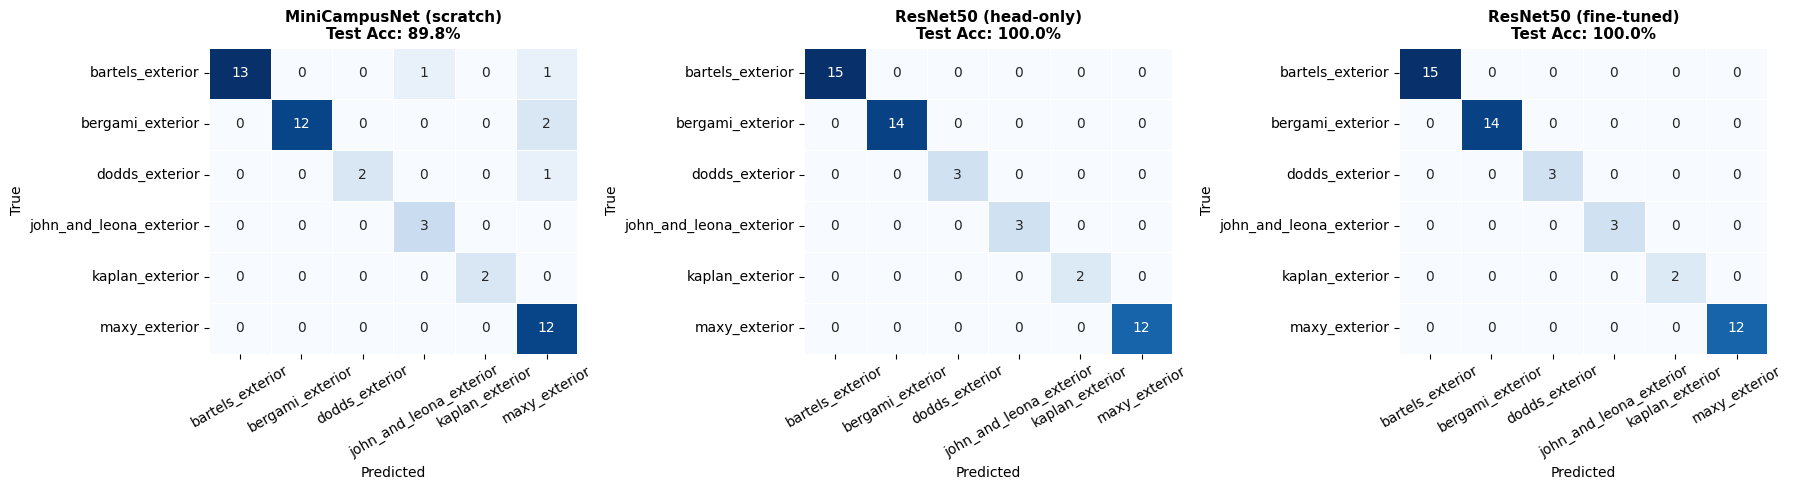

✓ Saved as comparison_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, results):
    cm = confusion_matrix(r["labels"], r["preds"])
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=classes, yticklabels=classes,
                cmap="Blues", linewidths=0.5, cbar=False, ax=ax)
    ax.set_title(f"{r['name']}\nTest Acc: {r['accuracy']:.1f}%",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as comparison_confusion_matrices.png")

## Cell 7 — Summary bar charts: accuracy, params, latency

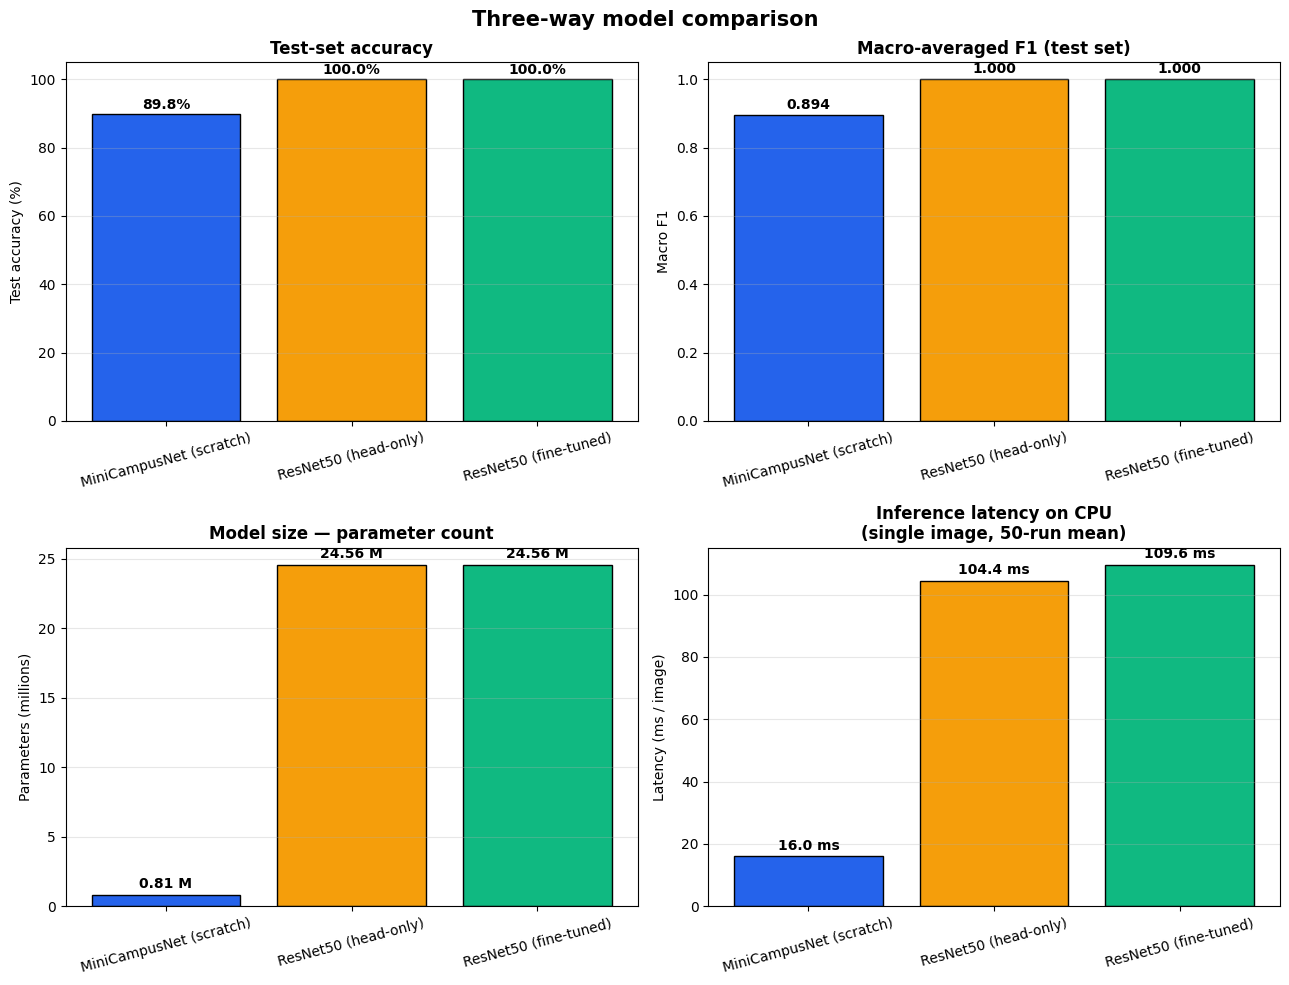

✓ Saved as comparison_summary.png


In [11]:
names    = [r["name"] for r in results]
accs     = [r["accuracy"]   for r in results]
params_m = [r["params"]/1e6 for r in results]   # millions
lats     = [r["latency_ms"] for r in results]
f1s      = [r["macro_f1"]   for r in results]

colors = ["#2563EB", "#F59E0B", "#10B981"]   # mini, frozen, ft

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Accuracy
ax = axes[0, 0]
bars = ax.bar(names, accs, color=colors, edgecolor="black")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Test-set accuracy", fontweight="bold")
ax.set_ylim(0, 105)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5,
            f"{v:.1f}%", ha="center", fontweight="bold")
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

# Macro F1
ax = axes[0, 1]
bars = ax.bar(names, f1s, color=colors, edgecolor="black")
ax.set_ylabel("Macro F1")
ax.set_title("Macro-averaged F1 (test set)", fontweight="bold")
ax.set_ylim(0, 1.05)
for b, v in zip(bars, f1s):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02,
            f"{v:.3f}", ha="center", fontweight="bold")
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

# Parameter count (log-ish via bar width labels)
ax = axes[1, 0]
bars = ax.bar(names, params_m, color=colors, edgecolor="black")
ax.set_ylabel("Parameters (millions)")
ax.set_title("Model size — parameter count", fontweight="bold")
for b, v in zip(bars, params_m):
    ax.text(b.get_x() + b.get_width()/2, v + max(params_m)*0.02,
            f"{v:.2f} M", ha="center", fontweight="bold")
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

# Latency
ax = axes[1, 1]
bars = ax.bar(names, lats, color=colors, edgecolor="black")
ax.set_ylabel("Latency (ms / image)")
ax.set_title(f"Inference latency on {device.upper()}\n(single image, 50-run mean)",
             fontweight="bold")
for b, v in zip(bars, lats):
    ax.text(b.get_x() + b.get_width()/2, v + max(lats)*0.02,
            f"{v:.1f} ms", ha="center", fontweight="bold")
ax.tick_params(axis='x', rotation=15)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Three-way model comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as comparison_summary.png")

## Cell 8 — Accuracy-vs-parameters efficiency plot

The most insightful single chart for the report. Top-left = small + accurate (best). Bottom-right = big + inaccurate (worst).

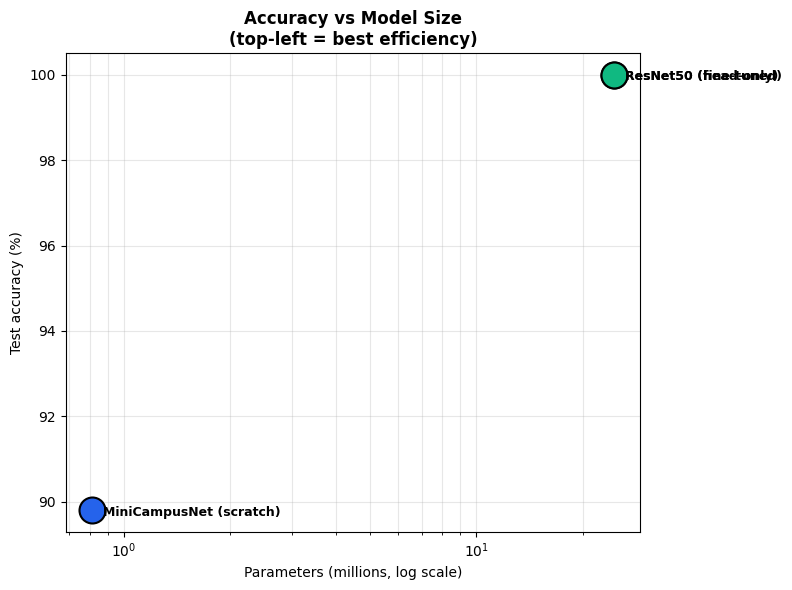

✓ Saved as comparison_efficiency.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
for r, c in zip(results, colors):
    ax.scatter(r["params"]/1e6, r["accuracy"], s=350, color=c,
               edgecolor="black", linewidth=1.5, label=r["name"], zorder=3)
    ax.annotate(r["name"],
                xy=(r["params"]/1e6, r["accuracy"]),
                xytext=(8, -4), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.set_xscale("log")
ax.set_xlabel("Parameters (millions, log scale)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Accuracy vs Model Size\n(top-left = best efficiency)",
             fontweight="bold")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("comparison_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as comparison_efficiency.png")

## Cell 9 — Save metrics to JSON for the report

In [13]:
summary = []
for r in results:
    summary.append({
        "name"      : r["name"],
        "params"    : int(r["params"]),
        "file_mb"   : round(r["file_mb"], 2),
        "accuracy"  : round(r["accuracy"], 2),
        "macro_f1"  : round(r["macro_f1"], 4),
        "latency_ms": round(r["latency_ms"], 2),
    })
with open("comparison_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\n✓ Saved as comparison_metrics.json")

[
  {
    "name": "MiniCampusNet (scratch)",
    "params": 809798,
    "file_mb": 3.16,
    "accuracy": 89.8,
    "macro_f1": 0.8943,
    "latency_ms": 15.97
  },
  {
    "name": "ResNet50 (head-only)",
    "params": 24560198,
    "file_mb": 94.0,
    "accuracy": 100.0,
    "macro_f1": 1.0,
    "latency_ms": 104.36
  },
  {
    "name": "ResNet50 (fine-tuned)",
    "params": 24560198,
    "file_mb": 94.0,
    "accuracy": 100.0,
    "macro_f1": 1.0,
    "latency_ms": 109.58
  }
]

✓ Saved as comparison_metrics.json
